## Finetuned Model Post-Processing: Optuna & 4-Fold CV

**Heads**

Default: your custom head (for the dataset you gave `--train-file` earlier)

pt_head: pre-training/replay head, samples drawn from the replay .xyz file, a snapshot of the original foundation model's training set

Get current log of Optuna trial results and place in `cv-optuna/results` (run in CLI at repo root):

`scp <LONI-source-directory>/optuna_study.log mace-mh-1/cv-optuna/cv-results/optuna_study.log` \
`scp loni:/home/zschwab/mace-finetune/cv-optuna/optuna_study.log mace-mh-1/cv-optuna/cv-results/optuna_study.log`

Get training run .out logs to fetch error metrics by running `python build_job_ids.py` in LONI (FIX)

`scp loni:/home/zschwab/mace-finetune/cv-optuna/job_ids.json mace-mh-1/cv-optuna/cv-results/job_ids.json`

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import ast
from ase.io import read, write

# adjust to your paths
CV_ROOT = "/Users/zschwab/vscode/montemore-research/finetuned-mlips/mace-mh-1/cv-optuna/cv-results/"
STORAGE_PATH = f"{CV_ROOT}/optuna_study.log"

plt.rcParams["figure.dpi"] = 110

In [51]:
storage = optuna.storages.JournalStorage(
    optuna.storages.JournalFileStorage(STORAGE_PATH)
)
summaries = optuna.study.get_all_study_summaries(storage=storage)
assert len(summaries) == 1, f"expected 1 study, found: {[s.study_name for s in summaries]}"
study_name = summaries[0].study_name
study = optuna.load_study(study_name=study_name, storage=storage)

df = study.trials_dataframe()
df = df[df["state"] == "COMPLETE"].copy()

# expand fold-level lists (stored as strings by trials_dataframe -> literal_eval)
df["fold_rmse_e"] = df["user_attrs_fold_rmse_e"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
df["fold_rmse_f"] = df["user_attrs_fold_rmse_f"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
df = df.drop(columns=["user_attrs_fold_rmse_e", "user_attrs_fold_rmse_f"])

df["RMSE_E"] = df["fold_rmse_e"].apply(lambda x: sum(x) / len(x))
df["RMSE_F"] = df["fold_rmse_f"].apply(lambda x: sum(x) / len(x))

param_cols = [c for c in df.columns if c.startswith("params_")]
front = ["number", "value", "RMSE_E", "RMSE_F", "fold_rmse_e", "fold_rmse_f"]
back = ["datetime_start", "datetime_complete"]
middle = [c for c in df.columns if c not in front + back + param_cols]

df = df[front + param_cols + middle + back]

df.sort_values("value")

/var/folders/nq/bjj6kssx74500m34s24x3mf00000gn/T/ipykernel_88630/1930367465.py:2: FutureWarning: JournalFileStorage has been deprecated in v4.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.0.0. Use :class:`~optuna.storages.journal.JournalFileBackend` instead.
  optuna.storages.JournalFileStorage(STORAGE_PATH)


,number,value,RMSE_E,RMSE_F,fold_rmse_e,fold_rmse_f,params_lr,params_swa_energy_weight,params_swa_forces_weight,params_swa_lr,params_weight_decay,duration,user_attrs_fold_std,state,datetime_start,datetime_complete
10,10,27.419375,31.4225,19.9850,"[16.02, 21.3, 16.43, 71.94]","[19.62, 20.96, 18.59, 20.77]",0.000470,9.490267,60.146578,0.000095,4.785872e-08,0 days 01:56:03.771381,17.838144,COMPLETE,2026-08-04 11:01:27.679581,2026-08-04 12:57:31.450962
11,11,27.438500,31.3900,20.1000,"[16.01, 21.35, 16.54, 71.66]","[19.75, 21.04, 18.71, 20.9]",0.000442,9.869746,57.905391,0.000088,5.579140e-08,0 days 01:56:04.623885,17.734147,COMPLETE,2026-08-04 12:57:31.454747,2026-08-04 14:53:36.078632
7,7,27.795125,32.0275,19.9350,"[17.95, 21.49, 19.04, 69.63]","[19.59, 20.89, 18.6, 20.66]",0.000034,9.469520,100.183668,0.000061,1.414847e-08,0 days 01:56:03.136860,16.508934,COMPLETE,2026-08-04 05:13:46.743309,2026-08-04 07:09:49.880169
9,9,27.917500,32.4500,19.5000,"[18.6, 21.48, 20.02, 69.7]","[19.24, 20.47, 18.12, 20.17]",0.000027,5.435109,111.289453,0.000094,2.012310e-08,0 days 01:55:34.319542,16.327703,COMPLETE,2026-08-04 09:05:53.304180,2026-08-04 11:01:27.623722
12,12,28.169750,32.3400,20.4250,"[18.94, 21.98, 20.03, 68.41]","[19.99, 21.39, 19.07, 21.25]",0.000491,9.836698,53.840665,0.000044,5.198611e-08,0 days 01:55:33.526741,15.859849,COMPLETE,2026-08-04 14:53:36.100637,2026-08-04 16:49:09.627378
6,6,28.882625,33.3600,20.5675,"[21.8, 23.4, 24.91, 63.33]","[20.17, 21.61, 19.1, 21.39]",0.000014,5.190008,92.583029,0.000007,1.480971e-08,0 days 01:56:02.858761,13.200428,COMPLETE,2026-08-04 03:17:43.881448,2026-08-04 05:13:46.740209
4,4,29.061750,33.8200,20.2250,"[21.56, 23.98, 23.75, 65.99]","[19.84, 21.2, 18.86, 21.0]",0.000120,6.304723,122.244338,0.000028,1.961512e-07,0 days 01:56:03.155436,14.145946,COMPLETE,2026-08-03 23:26:07.594953,2026-08-04 01:22:10.750389
1,1,29.133500,33.8550,20.3650,"[21.86, 23.95, 24.5, 65.11]","[19.92, 21.37, 19.0, 21.17]",0.000052,5.068853,89.211752,0.000023,4.436629e-07,0 days 01:55:33.100061,13.754498,COMPLETE,2026-08-03 17:39:27.657011,2026-08-03 19:35:00.757072
0,0,29.186875,33.7500,20.7125,"[22.24, 24.23, 25.27, 63.26]","[20.43, 21.7, 19.26, 21.46]",0.000153,5.737490,121.946897,0.000003,5.919452e-09,0 days 01:57:04.759093,12.985575,COMPLETE,2026-08-03 15:42:22.847713,2026-08-03 17:39:27.606806
14,14,29.189625,33.8700,20.4975,"[21.79, 24.18, 23.92, 65.59]","[20.1, 21.41, 19.18, 21.3]",0.000253,7.763052,71.546069,0.000019,5.389688e-08,0 days 01:55:33.627098,13.956800,COMPLETE,2026-08-04 18:45:43.585216,2026-08-04 20:41:17.212314


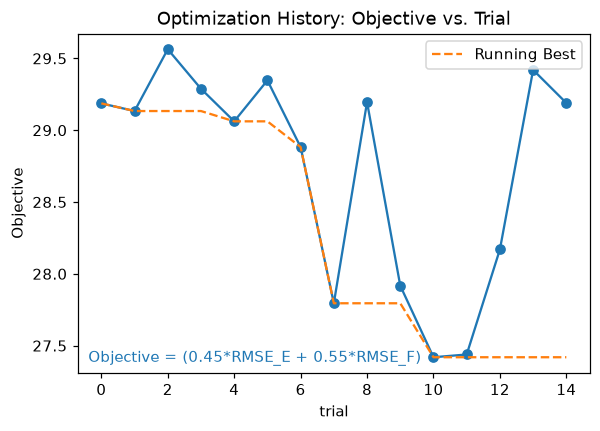

Objective: composite score (meV/atom + meV/Å, weighted)


In [52]:
# optimization history
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df["number"], df["value"], "o-")
running_best = df.sort_values("number")["value"].cummin()
ax.plot(df.sort_values("number")["number"], running_best, "--", label="Running Best")
ax.set_xlabel("trial")
ax.set_ylabel("Objective")
ax.set_title("Optimization History: Objective vs. Trial")
ax.text(0.02, 0.02, 
        "Objective = (0.45*RMSE_E + 0.55*RMSE_F)", 
        transform=ax.transAxes, ha="left", va="bottom",
        color="tab:blue")
ax.legend()
plt.show()

print("Objective: composite score (meV/atom + meV/Å, weighted)")

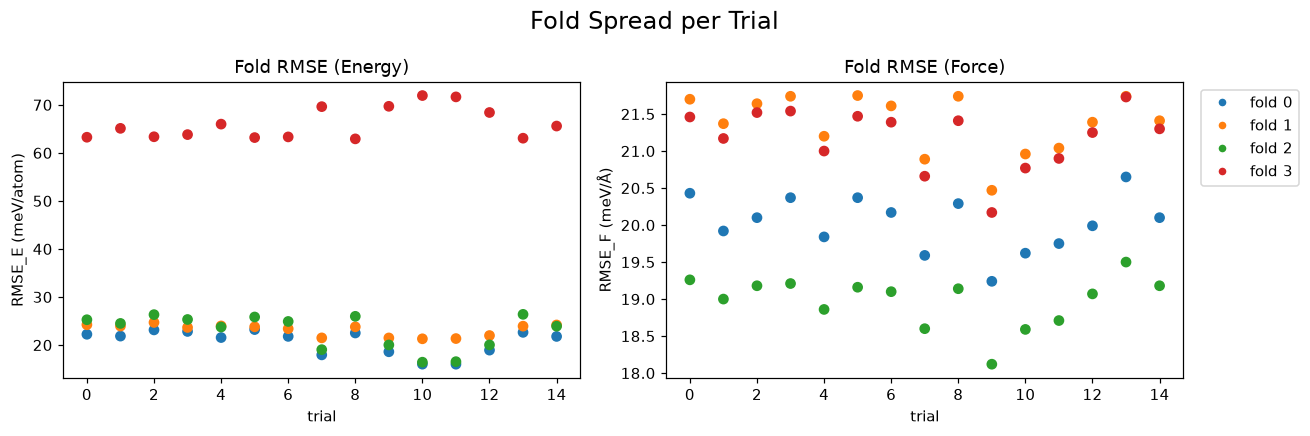

In [53]:
# fold spread per trial (outlier check)
n_folds = len(df["fold_rmse_e"].iloc[0])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for metric_idx, (metric_name, ax) in enumerate(zip(["fold_rmse_e", "fold_rmse_f"], axes)):
    for _, row in df.sort_values("number").iterrows():
        vals = row[metric_name]
        xs = [row["number"]] * n_folds
        ax.scatter(xs, vals, c=range(n_folds), cmap="tab10", vmin=0, vmax=9)
    ax.set_xlabel("trial")
    y_name = "RMSE_E (meV/atom)" if metric_name == "fold_rmse_e" else "RMSE_F (meV/Å)"
    ax.set_ylabel(y_name)
    title_name = "Fold RMSE (Energy)" if metric_name == "fold_rmse_e" else "Fold RMSE (Force)"
    ax.set_title(title_name)

# legend for fold colors
handles = [plt.Line2D([0], [0], marker="o", color="w",
                        markerfacecolor=plt.cm.tab10(i / 9), label=f"fold {i}")
            for i in range(n_folds)]
axes[1].legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1))
fig.suptitle("Fold Spread per Trial", fontsize=16)
fig.tight_layout()
plt.show()

In [54]:
importances = optuna.importance.get_param_importances(study)
for param, imp in importances.items():
    print(f"{param:20s} {imp:.3f}")

swa_lr               0.706
swa_energy_weight    0.263
lr                   0.022
swa_forces_weight    0.009
weight_decay         0.000


# Final Training Run
#### Use hyperparameters from the lowest-error Optuna trial in the study and train on the entire test set (all 4 folds).

In [ ]:
best_row = df.loc[df["value"].idxmin()]
rmse_f = best_row["fold_rmse_f"]
rmse_e = best_row["fold_rmse_e"]

print(f"""best trial: #{int(best_row['number'])}
params: {study.best_params}

fold RMSE_F (meV/A):      {rmse_f}      mean RMSE_F: {np.mean(rmse_f):.3f}
fold RMSE_E (meV/atom):   {rmse_e}      mean RMSE_E: {np.mean(rmse_e):.3f}

final optimized value (0.45*RMSE_E + 0.55*RMSE_F): {best_row['value']:.4f}""")

After `scp`-ing `full_train.sh` over to your LONI directory, copy and paste the `sbatch` command printed below to run.

In [58]:
params = study.best_params

sbatch_cmd = (
    f"sbatch full_train.sh "
    f"{params['lr']} "
    f"{params['weight_decay']} "
    f"{params['swa_lr']} "
    f"{params['swa_energy_weight']} "
    f"{params['swa_forces_weight']}"
)

print(sbatch_cmd)

sbatch full_train.sh 0.00047031542728235995 4.785872129643814e-08 9.549912967601715e-05 9.490266915712997 60.146577956482155


# Model Eval

Next, `scp` over your test set (`test.xyz`) and test eval files (`test_eval.py`, `test_eval.sh`) and run evaluation of final model on test set. \
Run this script with the paths to your test set, model, and desired output location on LONI:
```bash
sbatch test_eval.sh \
    /work/zschwab/mace-finetune/data/test.xyz \
    /work/zschwab/mace-finetune/final-run-740929/checkpoints/full_run_run-123_stagetwo.model \
    /work/zschwab/mace-finetune/final-run-740929/results/test_eval.json
```
Then `scp` your `test.json` into `mace-mh-1/results/` and assess below.

Optional: if your results look weird (eg. validation err is lower than train err, zero-shot on test set has lower err than the final full training run), try running the zero-shot on the train set.
```bash
sbatch test_eval.sh \
    /work/zschwab/mace-finetune/data/train_withNi_noO2.xyz \
    /work/zschwab/mace-finetune/final-run-740929/checkpoints/full_run_run-123_stagetwo.model \
    /work/zschwab/mace-finetune/final-run-740929/results/train_eval.json
```

In [4]:
import json

# ===== USER INPUT =====
JOB_ID = "740929"  # give LONI job_id/other distinguishing feature of your eval .json
# ======================

with open(f"../results/test_eval-{JOB_ID}.json") as f:
    d = json.load(f)

print(f"n_configs: {d['n_configs']}")
print(f"RMSE_E: {d['RMSE_E_per_atom_meV']:.2f} meV/atom")
print(f"RMSE_F: {d['RMSE_F_meV_per_A']:.2f} meV/A")

configs = d["per_config"]
e_errs = [c["E_error_meV_per_atom"] for c in configs]
f_rmses = [c["F_RMSE_meV_per_A"] for c in configs]

n_configs: 35
RMSE_E: 18.71 meV/atom
RMSE_F: 16.15 meV/A


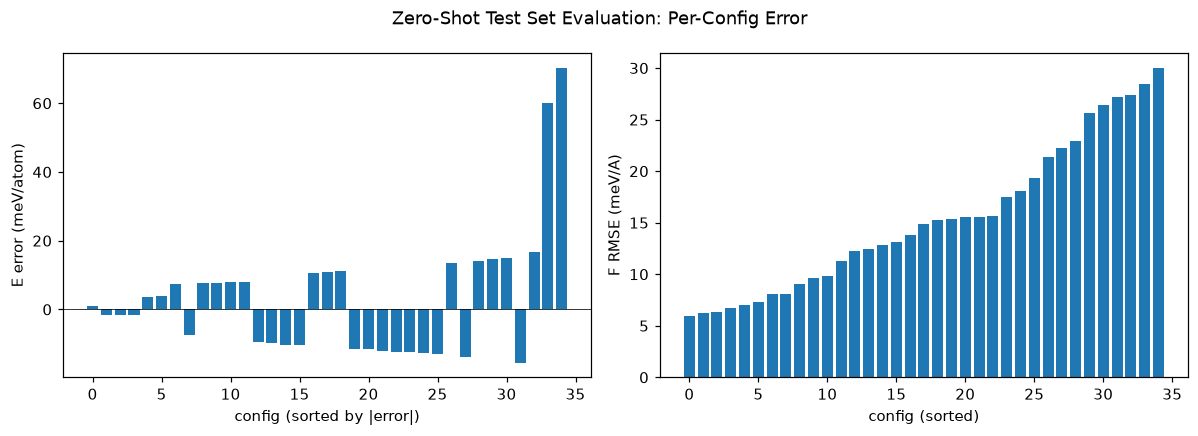

In [5]:
# positive bar: model overestimated; negative bar: model underestimated
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plt.suptitle("Zero-Shot Test Set Evaluation: Per-Config Error")

axes[0].bar(range(len(e_errs)), sorted(e_errs, key=abs))
axes[0].set_xlabel("config (sorted by |error|)")
axes[0].set_ylabel("E error (meV/atom)")
axes[0].axhline(0, color="k", lw=0.5)

axes[1].bar(range(len(f_rmses)), sorted(f_rmses))
axes[1].set_xlabel("config (sorted)")
axes[1].set_ylabel("F RMSE (meV/A)")

plt.tight_layout()
plt.show()

In [6]:
# highest-err configs on test set

worst_test = sorted(configs, key=lambda c: abs(c["E_error_meV_per_atom"]), reverse=True)[:10]
for c in worst_test:
    print(f"{c['formula']:15s} idx={c['index']:3d}  E_err={c['E_error_meV_per_atom']:7.1f} meV/atom  F_rmse={c['F_RMSE_meV_per_A']:6.1f} meV/A")

C3H5Ag35NiO4    idx=  3  E_err=   70.3 meV/atom  F_rmse=  30.0 meV/A
Ag75NiO5        idx=  2  E_err=   59.9 meV/atom  F_rmse=  28.5 meV/A
C2H4Ag76O6      idx= 24  E_err=   16.6 meV/atom  F_rmse=   9.0 meV/A
C2H4Ag109O4     idx= 13  E_err=  -15.5 meV/atom  F_rmse=  13.1 meV/A
C2H4Ag76O6      idx=  7  E_err=   14.9 meV/atom  F_rmse=  14.8 meV/A
C2H4Ag74O8      idx= 22  E_err=   14.7 meV/atom  F_rmse=  12.8 meV/A
C2H4Ag74O8      idx= 26  E_err=   14.1 meV/atom  F_rmse=  21.4 meV/A
C2H4Ag36O       idx=  8  E_err=  -13.8 meV/atom  F_rmse=  13.8 meV/A
C2H4Ag74O8      idx= 30  E_err=   13.4 meV/atom  F_rmse=  18.1 meV/A
Ag108O3         idx= 17  E_err=  -12.8 meV/atom  F_rmse=   5.9 meV/A


In [7]:
# zero-shot on training set

with open(f"../results/train_eval-{JOB_ID}.json") as f:
    d = json.load(f)

print(f"n_configs: {d['n_configs']}")
print(f"RMSE_E: {d['RMSE_E_per_atom_meV']:.2f} meV/atom")
print(f"RMSE_F: {d['RMSE_F_meV_per_A']:.2f} meV/A")

configs = d["per_config"]
e_errs = [c["E_error_meV_per_atom"] for c in configs]
f_rmses = [c["F_RMSE_meV_per_A"] for c in configs]

n_configs: 354
RMSE_E: 17.61 meV/atom
RMSE_F: 16.82 meV/A


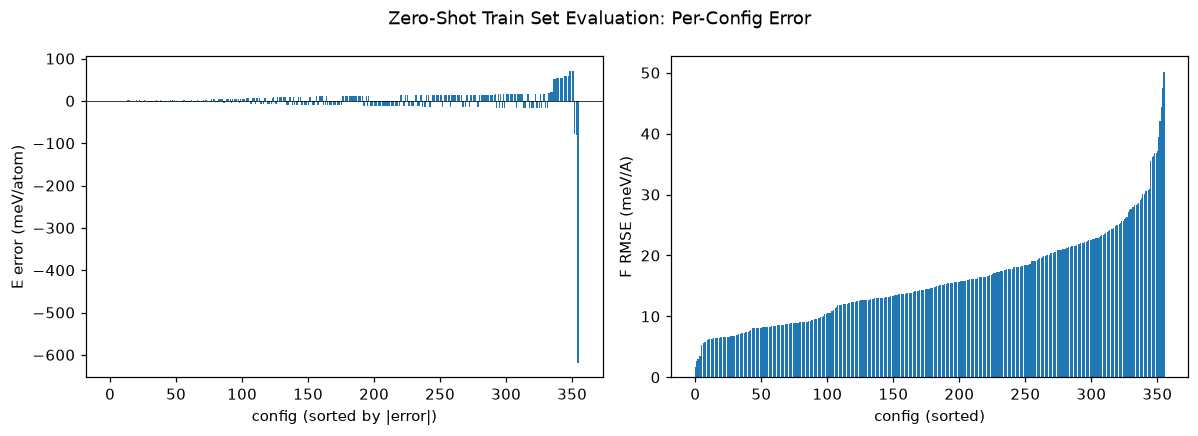

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plt.suptitle("Zero-Shot Train Set Evaluation: Per-Config Error")

axes[0].bar(range(len(e_errs)), sorted(e_errs, key=abs))
axes[0].set_xlabel("config (sorted by |error|)")
axes[0].set_ylabel("E error (meV/atom)")
axes[0].axhline(0, color="k", lw=0.5)

axes[1].bar(range(len(f_rmses)), sorted(f_rmses))
axes[1].set_xlabel("config (sorted)")
axes[1].set_ylabel("F RMSE (meV/A)")

plt.tight_layout()
plt.show()

In [67]:
# highest-err configs on train set

worst_train = sorted(configs, key=lambda c: abs(c["E_error_meV_per_atom"]), reverse=True)[:10]
for c in worst_train:
    print(f"{c['formula']:15s} idx={c['index']:3d}  E_err={c['E_error_meV_per_atom']:7.1f} meV/atom  F_rmse={c['F_RMSE_meV_per_A']:6.1f} meV/A")

O2              idx=251  E_err= -618.6 meV/atom  F_rmse=   7.2 meV/A
O2              idx=250  E_err= -618.6 meV/atom  F_rmse=   1.6 meV/A
C2H4            idx=194  E_err=  -79.5 meV/atom  F_rmse=  42.1 meV/A
C2H4            idx=195  E_err=  -77.8 meV/atom  F_rmse=   9.5 meV/A
C3H5Ag35NiO4    idx=115  E_err=   70.8 meV/atom  F_rmse=  30.9 meV/A
C3H5Ag35NiO4    idx=114  E_err=   70.8 meV/atom  F_rmse=  30.1 meV/A
C3H5Ag35NiO4    idx=311  E_err=   69.6 meV/atom  F_rmse=  27.6 meV/A
C3H5Ag35NiO4    idx=310  E_err=   69.6 meV/atom  F_rmse=  28.0 meV/A
Ag75NiO6        idx=  5  E_err=   59.6 meV/atom  F_rmse=  39.4 meV/A
Ag75NiO6        idx=  4  E_err=   59.3 meV/atom  F_rmse=  26.3 meV/A


In [73]:
# remove specific configs from train/test sets

FORMULA_TO_REMOVE = "O2"  # exact chemical_formula() match

# label: (input_xyz, output_xyz)
FILES = {
    "train": ("../../training-data/train.xyz",            "../../training-data/train_withNi_noO2.xyz"),
    "test":  ("../../training-data/folds/test.xyz",       "../../training-data/test_withNi_noO2.xyz"),
}

for label, (input_xyz, output_xyz) in FILES.items():
    configs = read(input_xyz, index=":")
    matches = [(i, a) for i, a in enumerate(configs) if a.get_chemical_formula() == FORMULA_TO_REMOVE]

    print(f"\n{label}: found {len(matches)} {FORMULA_TO_REMOVE} configs")
    for i, a in matches:
        print(f"  idx={i}  n_atoms={len(a)}  E={a.info.get('REF_energy')}")

    kept = [a for i, a in enumerate(configs) if a.get_chemical_formula() != FORMULA_TO_REMOVE]
    write(output_xyz, kept)
    print(f"  wrote {len(kept)}/{len(configs)} configs -> {output_xyz}")


train: found 2 O2 configs
  idx=250  n_atoms=2  E=-8.78607315
  idx=251  n_atoms=2  E=-8.78724292
  wrote 354/356 configs -> ../../training-data/train_withNi_noO2.xyz

test: found 1 O2 configs
  idx=18  n_atoms=2  E=-8.78724292
  wrote 35/36 configs -> ../../training-data/test_withNi_noO2.xyz


In [10]:
configs = read("../../training-data/withNi_EO_Project_reactivity_input.xyz", index=":")
print(len(configs))
FORMULA_TO_REMOVE = "O2"
kept = [a for a in configs if a.get_chemical_formula() != FORMULA_TO_REMOVE]
print(len(kept))

356
354
